# 1. Imports & Config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from lifelines.utils import concordance_index

DURATION_COL = 'duration'
EVENT_COL    = 'event'
MAX_T        = 60
RANDOM_STATE = 42

# 2. Load Processed Data

In [2]:
train = pd.read_parquet('/content/data/processed/train.parquet')
val   = pd.read_parquet('/content/data/processed/val.parquet')
test  = pd.read_parquet('/content/data/processed/test.parquet')

print(train.shape, val.shape, test.shape)

(463232, 37) (420801, 37) (1371471, 37)


# 3. FICO Averaging

In [3]:
for df in [train, val, test]:
    df['fico_score'] = (df['fico_range_low'] + df['fico_range_high']) / 2
    df.drop(columns=['fico_range_low', 'fico_range_high'], inplace=True)

# 4. Feature Columns

In [4]:
exclude = {DURATION_COL, EVENT_COL, 'fico_range_low', 'fico_range_high'}
feature_cols = [c for c in train.columns if c not in exclude]
print(len(feature_cols), 'features')
print(feature_cols)

34 features
['loan_amnt', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'term', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT', 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_educational', 'purpose_home_improvement', 'purpose_house', 'purpose_major_purchase', 'purpose_medical', 'purpose_moving', 'purpose_other', 'purpose_renewable_energy', 'purpose_small_business', 'purpose_vacation', 'purpose_wedding', 'verification_status_Source Verified', 'verification_status_Verified', 'fico_score']


# 5. Person-Period Expansion

In [5]:
def expand_to_person_period(df, feature_cols, duration_col, event_col, max_t):
    durations = np.minimum(df[duration_col].values.astype(int), max_t)
    events    = df[event_col].values
    features  = df[feature_cols].values.astype(np.float32)

    row_counts = durations  # borrower i contributes durations[i] rows
    total_rows = row_counts.sum()

    # for each output row, which borrower does it belong to?
    borrower_idx = np.repeat(np.arange(len(df)), row_counts)

    # t values: for borrower i with duration T, t = 1, 2, ..., T
    t_vals = np.concatenate([np.arange(1, T + 1) for T in durations]).astype(np.float32)

    # y=1 only on the last row of a borrower who had an event
    last_row = np.cumsum(row_counts) - 1
    y = np.zeros(total_rows, dtype=np.float32)
    y[last_row[events == 1]] = 1.0

    X = features[borrower_idx]  # (total_rows, n_features)

    df_out = pd.DataFrame(
        np.hstack([X, t_vals.reshape(-1, 1), y.reshape(-1, 1)]),
        columns=feature_cols + ['t', 'y']
    )
    return df_out

print('expanding train...')
train_pp = expand_to_person_period(train, feature_cols, DURATION_COL, EVENT_COL, MAX_T)
print('expanding val...')
val_pp   = expand_to_person_period(val,   feature_cols, DURATION_COL, EVENT_COL, MAX_T)

print(train_pp.shape)
print(val_pp.shape)
print('event rate in person-period:', train_pp['y'].mean().round(5))

expanding train...
expanding val...
(12498944, 36)
(10823278, 36)
event rate in person-period: 0.00609


# 6. Feature Scaling

In [6]:
scale_cols = feature_cols + ['t']

scaler = StandardScaler()
train_pp[scale_cols] = scaler.fit_transform(train_pp[scale_cols])
val_pp[scale_cols]   = scaler.transform(val_pp[scale_cols])

# 7. Fit Logistic Regression on Person-Period Data

In [7]:
X_train = train_pp[scale_cols].values
y_train = train_pp['y'].values

model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver='saga',
    n_jobs=-1,
    random_state=RANDOM_STATE
)
model.fit(X_train, y_train)

print('train log-loss convergence: done')

train log-loss convergence: done


# 8. Survival Curve Reconstruction

In [8]:
def predict_survival_curves(df, feature_cols, scaler, model, max_t, chunk_size=5000):
    n = len(df)
    feat = df[feature_cols].values.astype(np.float32)
    t_vals = np.arange(1, max_t + 1, dtype=np.float32)
    survival = np.empty((n, max_t), dtype=np.float32)

    for start in range(0, n, chunk_size):
        end = min(start + chunk_size, n)
        chunk = feat[start:end]                          # (chunk, p)
        c = end - start

        feat_rep = np.repeat(chunk, max_t, axis=0)       # (chunk*max_t, p)
        t_rep    = np.tile(t_vals, c).reshape(-1, 1)     # (chunk*max_t, 1)
        X        = np.hstack([feat_rep, t_rep])          # (chunk*max_t, p+1)

        X_scaled = scaler.transform(
            pd.DataFrame(X, columns=feature_cols + ['t'])
        )
        hazards = model.predict_proba(X_scaled)[:, 1].reshape(c, max_t)
        survival[start:end] = np.cumprod(1 - hazards, axis=1)

    return survival


print('predicting val survival curves...')
val_surv = predict_survival_curves(val, feature_cols, scaler, model, MAX_T)
print(val_surv.shape)

predicting val survival curves...
(420801, 60)


# 9. C-Statistic

In [9]:
def cstat_from_survival(surv_matrix, durations, events, t):
    """
    C-statistic at horizon t.
    Risk score = 1 - S(t), so higher risk <=> lower survival probability.
    lifelines concordance_index expects: higher score = longer survival,
    so we pass S(t) directly as the score.
    """
    t_idx = t - 1
    risk_score = surv_matrix[:, t_idx]
    return concordance_index(durations, risk_score, events)


for t in [12, 24, 36]:
    c = cstat_from_survival(
        val_surv,
        val[DURATION_COL].values,
        val[EVENT_COL].values,
        t
    )
    print(f't={t}: C-stat = {c:.4f}')

t=12: C-stat = 0.6850
t=24: C-stat = 0.6850
t=36: C-stat = 0.6850


# 10. Brier Score

In [10]:
def brier_score_at_t(surv_matrix, durations, events, t):
    """
    IPCW Brier score at a fixed horizon t.
    We use the simplified (unweighted) version here — consistent with 02_cox_ph.

    For each borrower i:
      - If T_i <= t and event: contribution = (0 - S_i(t))^2
      - If T_i > t (survived past t): contribution = (1 - S_i(t))^2
      - If T_i <= t and censored: excluded
    """
    t_idx = t - 1
    pred  = surv_matrix[:, t_idx]
    T     = np.array(durations)
    E     = np.array(events)

    mask_event    = (T <= t) & (E == 1)
    mask_survived = T > t

    bs = np.mean(
        np.where(mask_event,    (0 - pred) ** 2,
        np.where(mask_survived, (1 - pred) ** 2, np.nan))
        [~np.isnan(np.where(mask_event,    (0 - pred) ** 2,
                   np.where(mask_survived, (1 - pred) ** 2, np.nan)))]
    )
    return bs


for t in [12, 24, 36]:
    bs = brier_score_at_t(
        val_surv,
        val[DURATION_COL].values,
        val[EVENT_COL].values,
        t
    )
    print(f't={t}: Brier = {bs:.4f}')

t=12: Brier = 0.0625
t=24: Brier = 0.1512
t=36: Brier = 0.3064


# 11. Evaluation on Test Set

In [11]:
print('predicting test survival curves...')
test_surv = predict_survival_curves(test, feature_cols, scaler, model, MAX_T)

print('\ntest results')
for t in [12, 24, 36]:
    c  = cstat_from_survival(test_surv, test[DURATION_COL].values, test[EVENT_COL].values, t)
    bs = brier_score_at_t(test_surv, test[DURATION_COL].values, test[EVENT_COL].values, t)
    print(f't={t}: C-stat={c:.4f}  Brier={bs:.4f}')

predicting test survival curves...

test results
t=12: C-stat=0.6921  Brier=0.0729
t=24: C-stat=0.6921  Brier=0.2174
t=36: C-stat=0.6921  Brier=0.5297


# 12. Calibration Curves

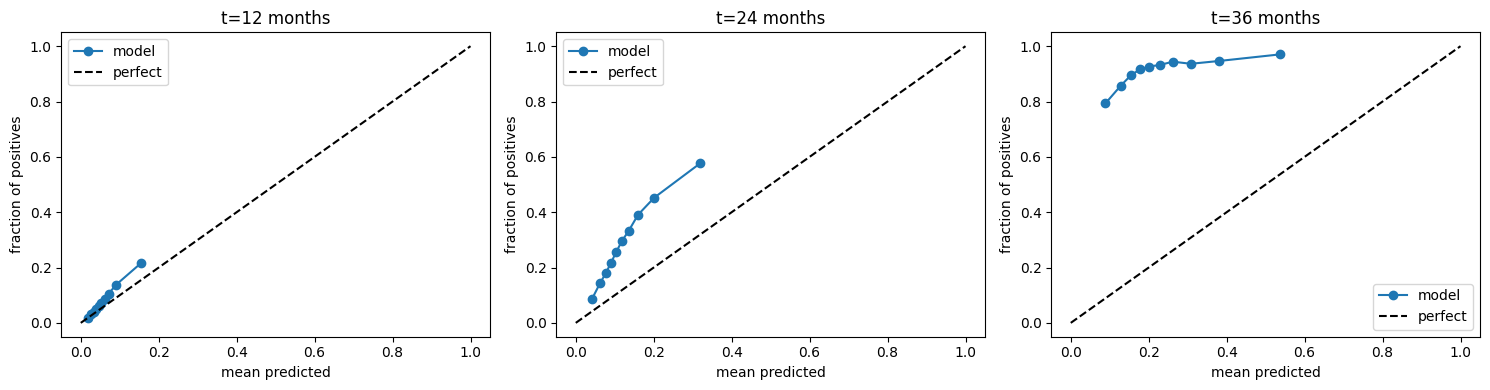

In [14]:
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, t in zip(axes, [12, 24, 36]):
    T = test[DURATION_COL].values
    E = test[EVENT_COL].values

    mask = (T <= t) & (E == 1) | (T > t)
    y_true_t = np.where(T[mask] <= t, 1, 0)
    # P(default by t) = 1 - S(t)
    y_pred_t = 1 - test_surv[mask, t - 1]

    frac_pos, mean_pred = calibration_curve(y_true_t, y_pred_t, n_bins=10, strategy='quantile')

    ax.plot(mean_pred, frac_pos, marker='o', label='model')
    ax.plot([0, 1], [0, 1], 'k--', label='perfect')
    ax.set_title(f't={t} months')
    ax.set_xlabel('mean predicted')
    ax.set_ylabel('fraction of positives')
    ax.legend()

plt.tight_layout()
import os
os.makedirs('outputs', exist_ok=True)
plt.savefig('outputs/calibration_discrete_hazard.png', dpi=120)
plt.show()

# 13. Sample Survival Curves

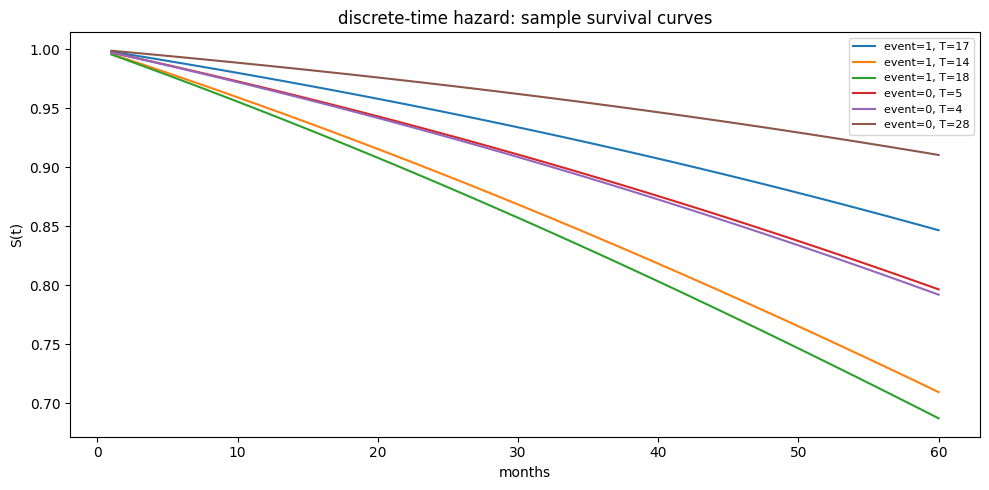

In [15]:
np.random.seed(RANDOM_STATE)
defaulted = test[test[EVENT_COL] == 1].sample(3)
censored  = test[test[EVENT_COL] == 0].sample(3)
samples   = pd.concat([defaulted, censored])

sample_surv = predict_survival_curves(samples, feature_cols, scaler, model, MAX_T)

fig, ax = plt.subplots(figsize=(10, 5))
t_axis = np.arange(1, MAX_T + 1)

for i, (_, row) in enumerate(samples.iterrows()):
    label = f"event={int(row[EVENT_COL])}, T={int(row[DURATION_COL])}"
    ax.plot(t_axis, sample_surv[i], label=label)

ax.set_xlabel('months')
ax.set_ylabel('S(t)')
ax.set_title('discrete-time hazard: sample survival curves')
ax.legend(fontsize=8)
plt.tight_layout()
import os
os.makedirs('outputs', exist_ok=True)
plt.savefig('outputs/survival_curves_discrete_hazard.png', dpi=120)
plt.show()